# 世界幸福指數預測與分群 (World Happiness ML Analysis)

本 Jupyter Notebook 為專案之**核心程式碼實作**。完整之研究背景、動機與結論探討，請參閱 [完整研究報告 PDF](./World_Happiness_Report.pdf)。

**涵蓋之實作流程：**
1. **資料預處理與探索性分析 (EDA)**：包含缺失值處理與特徵相關性分析 (Heatmap)。
2. **監督式學習 (線性迴歸)**：建立幸福指數預測模型 (R² = 0.843)。
3. **非監督式學習 (K-Means & PCA)**：運用主成分分析降維，並透過輪廓係數與階層式聚類進行全球幸福度分群。

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

In [49]:
# Colab 進行 matplotlib 繪圖時顯示繁體中文
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib
matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

print("✅ 中文字型設定完成！")

--2026-05-14 03:06:33--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 142.251.121.100, 142.251.121.113, 142.251.121.139, ...
Connecting to drive.google.com (drive.google.com)|142.251.121.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-05-14 03:06:33--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.121.132, 2607:f8b0:4023:80b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.121.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  56.4MB/s    in 0.3s    

2026-05-14 

## 📊 Step 1 : 探索性資料分析 (EDA) 與資料預處理

In [50]:
# 從 Kaggle 下載資料集
df_WHR = pd.read_csv('data/World-happiness-report-2024.csv')
df_WHR

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298
...,...,...,...,...,...,...,...,...,...,...,...,...
138,Congo (Kinshasa),Sub-Saharan Africa,3.295,3.462,3.128,0.534,0.665,0.262,0.473,0.189,0.072,1.102
139,Sierra Leone,Sub-Saharan Africa,3.245,3.366,3.124,0.654,0.566,0.253,0.469,0.181,0.053,1.068
140,Lesotho,Sub-Saharan Africa,3.186,3.469,2.904,0.771,0.851,0.000,0.523,0.082,0.085,0.875
141,Lebanon,Middle East and North Africa,2.707,2.797,2.616,1.377,0.577,0.556,0.173,0.068,0.029,-0.073


In [51]:
# 查看所有欄位名稱
df_WHR.columns

Index(['Country name', 'Regional indicator', 'Ladder score', 'upperwhisker',
       'lowerwhisker', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy', 'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Dystopia + residual'],
      dtype='object')

In [52]:
#挑選出需要欄位
target_col = ['Ladder score']
Features = ['Log GDP per capita' , 'Social support' , 'Healthy life expectancy' , 'Freedom to make life choices' , 'Generosity' , 'Perceptions of corruption']

In [53]:
df_WHR = df_WHR[ ['Country name'] +  ['Regional indicator'] + target_col + Features ]
df_WHR

,Country name,Regional indicator,Ladder score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,Western Europe,7.741,1.844,1.572,0.695,0.859,0.142,0.546
1,Denmark,Western Europe,7.583,1.908,1.520,0.699,0.823,0.204,0.548
2,Iceland,Western Europe,7.525,1.881,1.617,0.718,0.819,0.258,0.182
3,Sweden,Western Europe,7.344,1.878,1.501,0.724,0.838,0.221,0.524
4,Israel,Middle East and North Africa,7.341,1.803,1.513,0.740,0.641,0.153,0.193
...,...,...,...,...,...,...,...,...,...
138,Congo (Kinshasa),Sub-Saharan Africa,3.295,0.534,0.665,0.262,0.473,0.189,0.072
139,Sierra Leone,Sub-Saharan Africa,3.245,0.654,0.566,0.253,0.469,0.181,0.053
140,Lesotho,Sub-Saharan Africa,3.186,0.771,0.851,0.000,0.523,0.082,0.085
141,Lebanon,Middle East and North Africa,2.707,1.377,0.577,0.556,0.173,0.068,0.029


In [54]:
#檢視缺失值
df_WHR.isna().sum()

,0
Country name,0
Regional indicator,0
Ladder score,0
Log GDP per capita,3
Social support,3
Healthy life expectancy,3
Freedom to make life choices,3
Generosity,3
Perceptions of corruption,3


In [55]:
#刪除缺失值
df_WHR.dropna(inplace=True)

/tmp/ipykernel_894/3188683799.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WHR.dropna(inplace=True)


In [56]:
#檢視缺失值刪除結果
df_WHR.isna().sum()

,0
Country name,0
Regional indicator,0
Ladder score,0
Log GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


###選取重要特徵進行視覺化

/tmp/ipykernel_894/404018242.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regional indicator', y=col, data=df_regional_avg, ax=axes[idx], palette='viridis')
/tmp/ipykernel_894/404018242.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regional indicator', y=col, data=df_regional_avg, ax=axes[idx], palette='viridis')
/tmp/ipykernel_894/404018242.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Regional indicator', y=col, data=df_regional_avg, ax=axes[idx], palette='viridis')
/tmp/ipykernel_894/404018242.py:11: FutureW

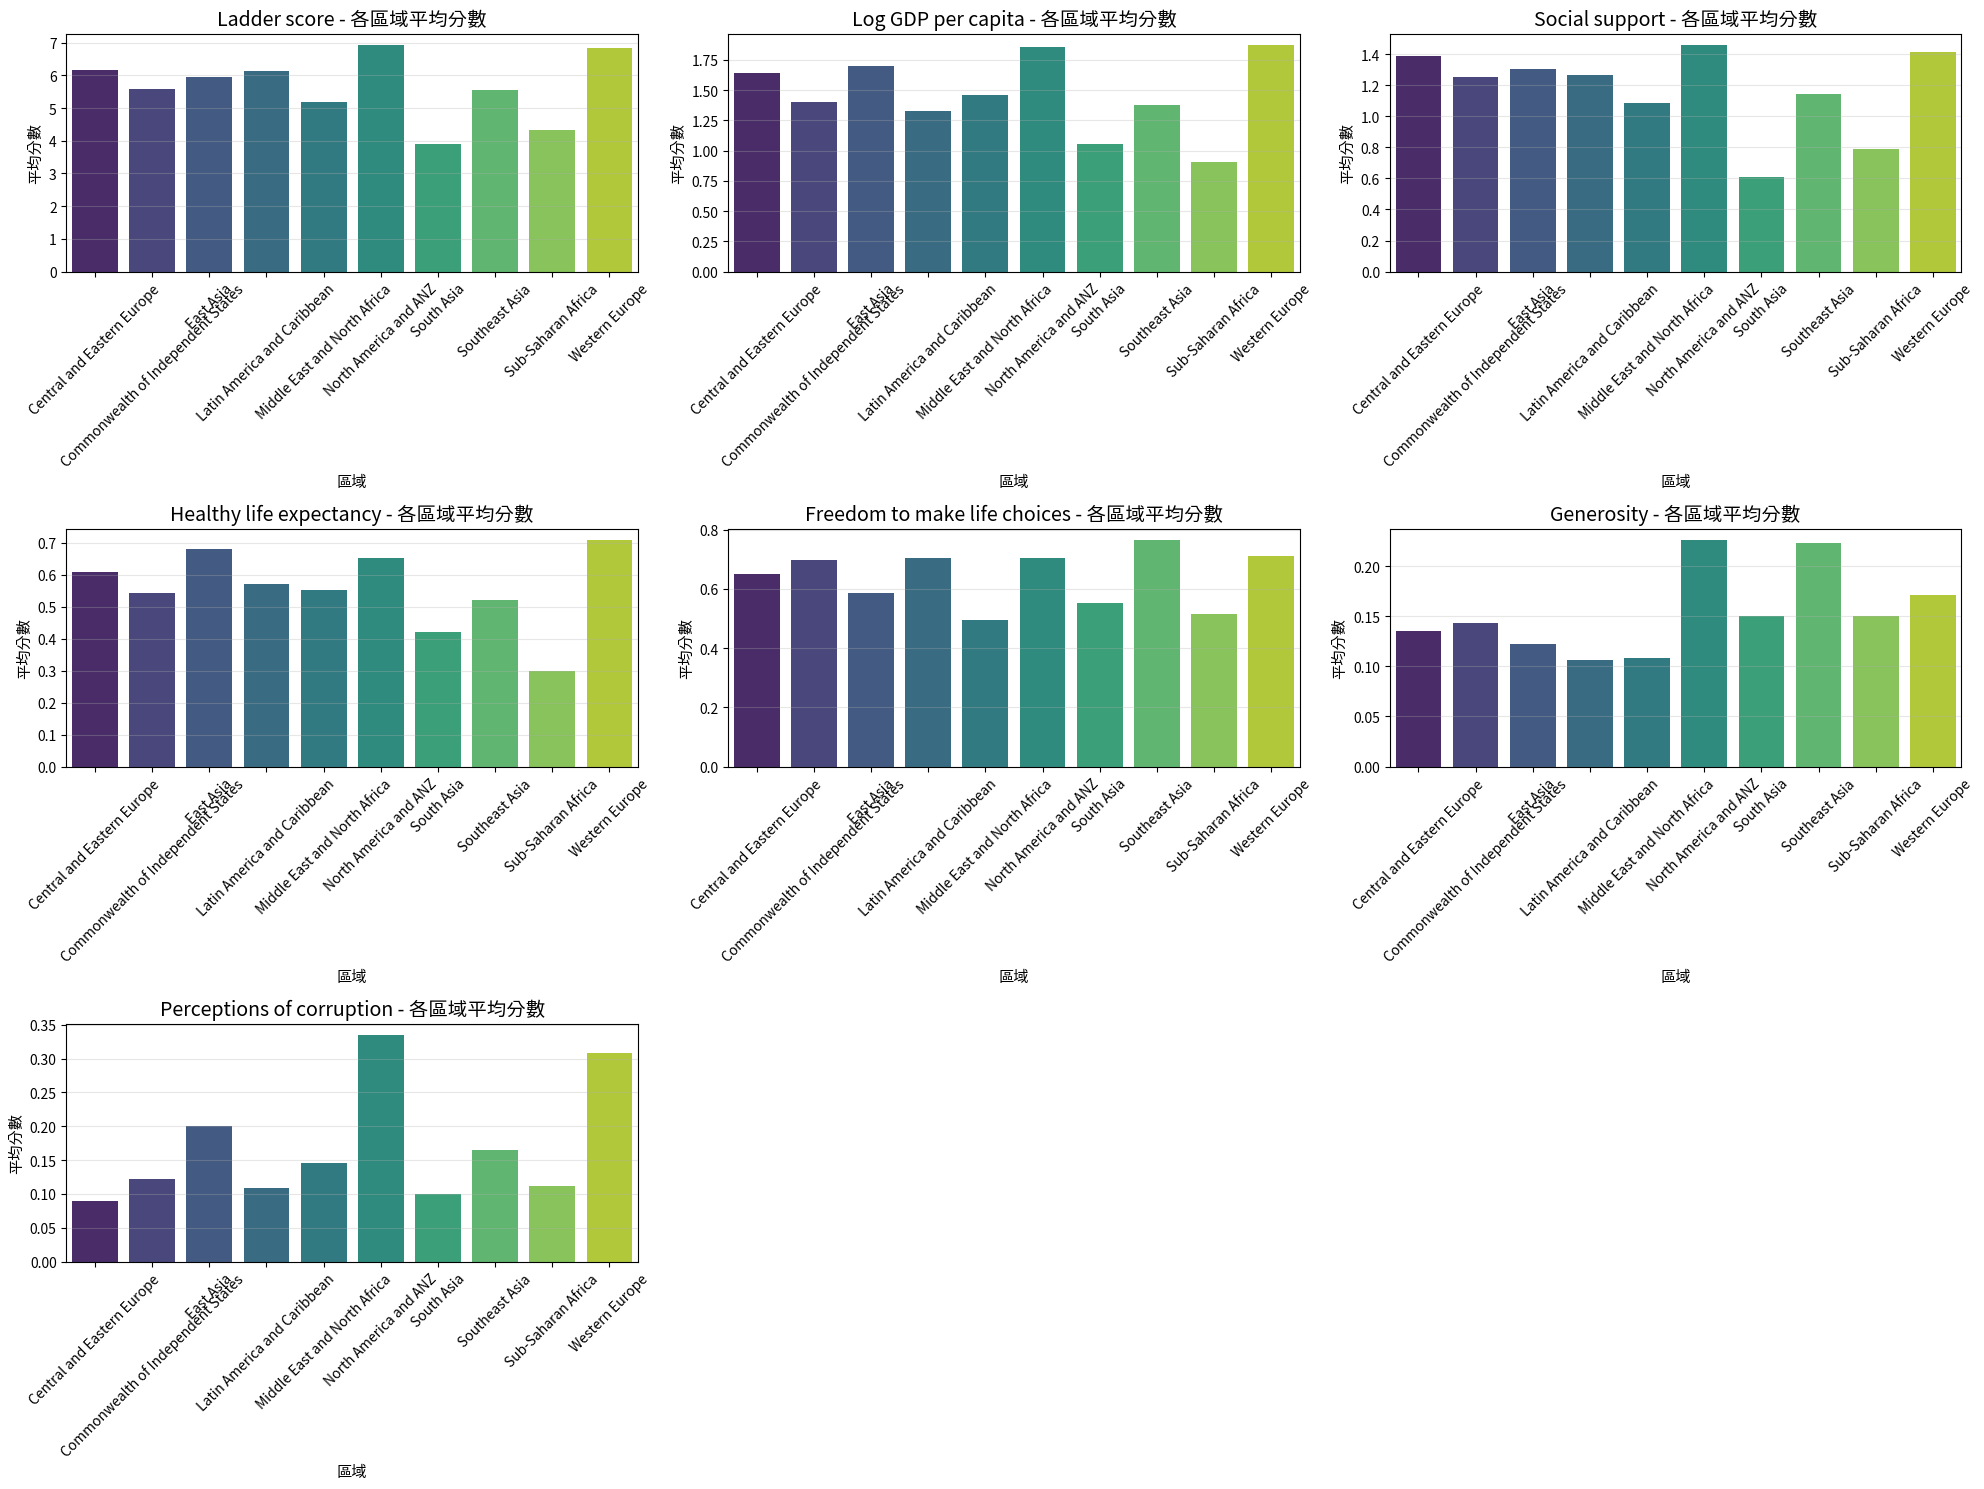

In [57]:
numerical_features = target_col + Features

# 計算每個區域數值特徵的平均值
df_regional_avg = df_WHR.groupby('Regional indicator')[numerical_features].mean().reset_index()

fig, axes = plt.subplots(3, 3, figsize=(20, 15)) # 調整為3x3以容納更多圖表
axes = axes.ravel() # 將axes攤平為一維陣列

for idx, col in enumerate(numerical_features):
    if idx < len(axes):
        sns.barplot(x='Regional indicator', y=col, data=df_regional_avg, ax=axes[idx], palette='viridis')
        axes[idx].set_title(f'{col} - 各區域平均分數', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('區域', fontsize=11)
        axes[idx].set_ylabel('平均分數', fontsize=11)
        axes[idx].tick_params(axis='x', rotation=45) # 旋轉X軸標籤以避免重疊
        axes[idx].grid(axis='y', alpha=0.3)

# 隱藏多餘的子圖 (如果 numerical_features 數量少於子圖總數)
for i in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [58]:
#相關係數矩陣
correlation_matrix = df_WHR[target_col + Features].corr()

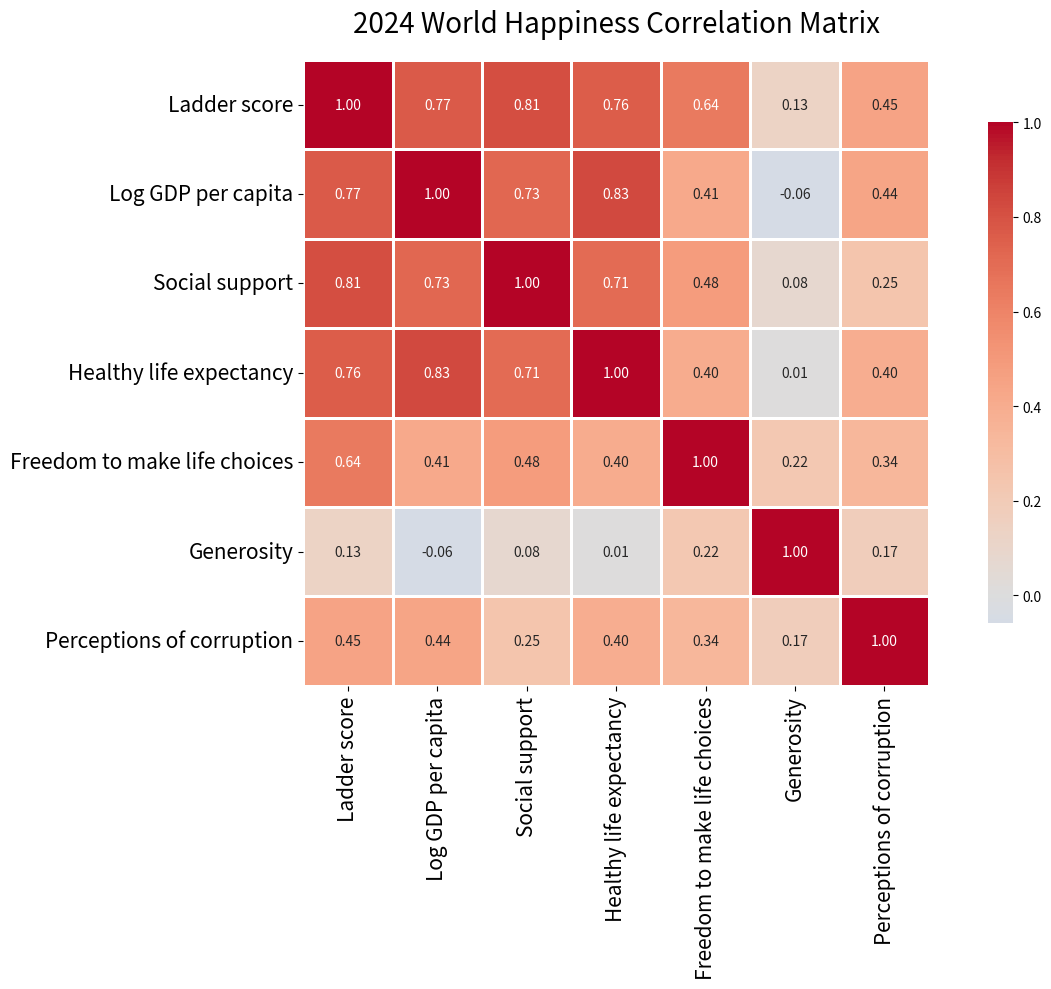

In [59]:
# 畫出熱力圖
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('2024 World Happiness Correlation Matrix', fontsize=20, fontweight='bold', pad=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

In [60]:
print("💡 高度相關的特徵對：")
# 找出高度相關的特徵對 (相關係數 > 0.7)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((correlation_matrix.columns[i],
                            correlation_matrix.columns[j],
                            correlation_matrix.iloc[i, j]))

# 依照相關係數大小降序排列並印出結果
high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

for pair in high_corr_pairs[:5]:  # 顯示前5組
    print(f"  - {pair[0]} vs {pair[1]}: {pair[2]:.3f}")

💡 高度相關的特徵對：
  - Log GDP per capita vs Healthy life expectancy: 0.830
  - Ladder score vs Social support: 0.814
  - Ladder score vs Log GDP per capita: 0.769
  - Ladder score vs Healthy life expectancy: 0.760
  - Log GDP per capita vs Social support: 0.727


### === 經濟意義解讀 ===
###### 1. "Log GDP per capita" 與 "Healthy life expectancy" (0.83): 經濟越好，醫療越好。
###### 2. "Log GDP per capita" 與 "Social support" (0.73): 人均 GDP 與社會支持度 呈現中高度相關。
###### 3. "Ladder score" 與 "Social support" (0.81): 社會支持度對幸福感的影響 超過 GDP對幸福感的影響 (0.77)。
###### 4. "Ladder score" 與 "Healthy life expectancy" (0.76): 健康預期壽命對幸福感的影響也顯著, 但稍遜於GDP對幸福感的影響 (0.77)。

#📊 Step 2. 模型分析

## 監督式學習：線性迴歸 (Linear Regression)
#### 目標：找出哪些因素最能預測幸福感？

In [61]:
X = df_WHR[Features]
y = df_WHR[target_col]

# 1. 切分訓練集 (80%) 與測試集 (20%)
# random_state=42 是一個常用的數字，確保每次切分的結果都一樣，方便重現實驗
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # train_test_split的輸出值可能有多個，讓輸出值能直接對應前面的變數


In [62]:
print(f"原始資料總筆數: {len(df_WHR)}")
print(f"訓練集資料筆數: {len(X_train)}")
print(f"測試集資料筆數: {len(X_test)}")

原始資料總筆數: 140
訓練集資料筆數: 112
測試集資料筆數: 28


In [63]:
# 2. 建立模型實例 (Instance)
model = LinearRegression()

# 3. 訓練模型 (Fit the model)
model.fit(X_train ,y_train)
y_pred = model.predict(X_test)

In [64]:
# 評估模型表現
print("\n=== 線性迴歸模型評估 ===")
print(f"R-squared (解釋力): {r2_score(y_test, y_pred):.4f}")
print("  -> 這表示變數能解釋約 84% 的幸福分數變化。")

# 顯示係數: 哪個變數影響最大？
print("\n=== 影響幸福感的關鍵因素 (係數) ===")
coef_df = pd.DataFrame({'Features': Features, 'Coefficient': model.coef_[0]})

# 按照係數大小排序
print(coef_df.sort_values(by='Coefficient', ascending=False))


=== 線性迴歸模型評估 ===
R-squared (解釋力): 0.8430
  -> 這表示變數能解釋約 84% 的幸福分數變化。

=== 影響幸福感的關鍵因素 (係數) ===
                       Features  Coefficient
3  Freedom to make life choices     1.748104
1                Social support     1.367474
2       Healthy life expectancy     1.343421
5     Perceptions of corruption     1.166164
0            Log GDP per capita     0.478129
4                    Generosity     0.399807


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


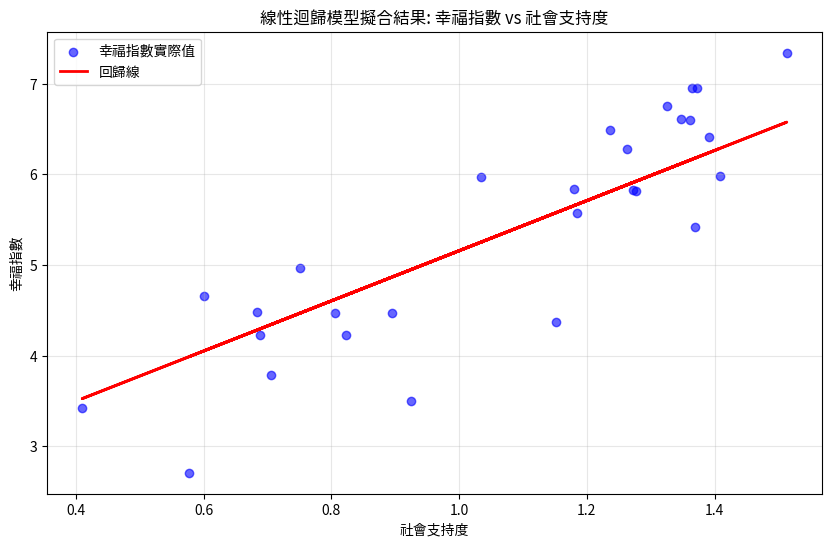

In [65]:
# 設定變數：只選取 'Social support' 作為特徵，'Ladder score' 作為目標
# 這是為了能在二維平面上畫出一條單純的「直線」
X1 = df_WHR[['Social support']]  # 必須是 DataFrame 格式 (二維)
y = df_WHR['Ladder score']

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X1_train, y_train)
y_pred = model.predict(X1_test)

# 視覺化：散佈圖 + 回歸線
plt.figure(figsize=(10, 6))

# 畫出測試集的真實數據點 (散佈圖)
plt.scatter(X1_test, y_test, color='blue', alpha=0.6, label='幸福指數實際值')

# 畫出模型預測的直線
X1_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred = model.predict(X1_range)
plt.plot(X1_test, y_pred, color='red', linewidth=2, label='回歸線')

# 加上標題與標籤
plt.title('線性迴歸模型擬合結果: 幸福指數 vs 社會支持度')
plt.xlabel('社會支持度')
plt.ylabel('幸福指數')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


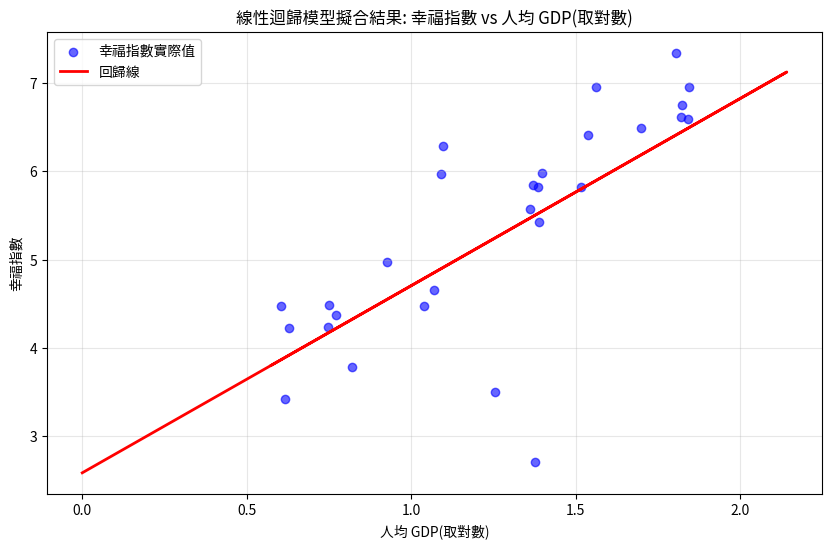

In [66]:
# 設定變數：只選取 'Log GDP per capita' 作為特徵，'Ladder score' 作為目標
# 這是為了能在二維平面上畫出一條單純的「直線」
X2 = df_WHR[['Log GDP per capita']]  # 必須是 DataFrame 格式 (二維) 根據欲預測資料再作切分
y = df_WHR['Ladder score']

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X2_train, y_train)
y_pred = model.predict(X2_test)

# 視覺化：散佈圖 + 回歸線
plt.figure(figsize=(10, 6))

# 畫出測試集的真實數據點 (散佈圖)
plt.scatter(X2_test, y_test, color='blue', alpha=0.6, label='幸福指數實際值')

# 畫出模型預測的直線
X2_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred = model.predict(X2_range)
plt.plot(X2_range, y_range_pred, color='red', linewidth=2, label='回歸線')

# 加上標題與標籤
plt.title('線性迴歸模型擬合結果: 幸福指數 vs 人均 GDP(取對數)')
plt.xlabel('人均 GDP(取對數)')
plt.ylabel('幸福指數')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 非監督式學習：
#### 目標：將國家自動分成「相似」的群體

###資料標準化

In [67]:
df_WHR

,Country name,Regional indicator,Ladder score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,Western Europe,7.741,1.844,1.572,0.695,0.859,0.142,0.546
1,Denmark,Western Europe,7.583,1.908,1.520,0.699,0.823,0.204,0.548
2,Iceland,Western Europe,7.525,1.881,1.617,0.718,0.819,0.258,0.182
3,Sweden,Western Europe,7.344,1.878,1.501,0.724,0.838,0.221,0.524
4,Israel,Middle East and North Africa,7.341,1.803,1.513,0.740,0.641,0.153,0.193
...,...,...,...,...,...,...,...,...,...
138,Congo (Kinshasa),Sub-Saharan Africa,3.295,0.534,0.665,0.262,0.473,0.189,0.072
139,Sierra Leone,Sub-Saharan Africa,3.245,0.654,0.566,0.253,0.469,0.181,0.053
140,Lesotho,Sub-Saharan Africa,3.186,0.771,0.851,0.000,0.523,0.082,0.085
141,Lebanon,Middle East and North Africa,2.707,1.377,0.577,0.556,0.173,0.068,0.029


In [68]:
# 排除非數值欄位 ('Country name', 'Regional indicator') 再進行標準化
# 只選擇數值型特徵進行標準化
scaler = StandardScaler()
df_WHR_numerical = df_WHR[Features + target_col]
df_WHR_scaled = scaler.fit_transform(df_WHR_numerical)
df_WHR_scaled = pd.DataFrame(df_WHR_scaled, columns = df_WHR_numerical.columns)
df_WHR_scaled

,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score
0,1.098248,1.317793,1.059525,1.472287,-0.058370,3.115426,1.877713
1,1.249342,1.161225,1.083865,1.249941,0.788873,3.131326,1.743476
2,1.185599,1.453284,1.199485,1.225236,1.526794,0.221634,1.694199
3,1.178516,1.104018,1.235996,1.342585,1.021182,2.940526,1.540421
4,1.001453,1.140149,1.333360,0.125863,0.091947,0.309084,1.537872
...,...,...,...,...,...,...,...
135,-1.994458,-1.413110,-1.575378,-0.911747,0.583895,-0.652863,-1.899621
136,-1.711156,-1.711191,-1.630145,-0.936452,0.474573,-0.803913,-1.942101
137,-1.434938,-0.853079,-3.169707,-0.602935,-0.878283,-0.549514,-1.992228
138,-0.004266,-1.678071,0.213678,-2.764624,-1.069595,-0.994713,-2.399187


In [69]:
print("--- 標準化前後對比 ---")
print("\n原始資料統計：")
print(df_WHR_numerical.describe().loc[['mean', 'std']].round(2))

print("\n標準化後統計：")
print(df_WHR_scaled.describe().loc[['mean', 'std']].round(2))

print("\n✅ 特徵標準化完成！所有特徵現在具有相同的尺度。")

--- 標準化前後對比 ---

原始資料統計：
      Log GDP per capita  Social support  Healthy life expectancy  \
mean                1.38            1.13                     0.52   
std                 0.43            0.33                     0.16   

      Freedom to make life choices  Generosity  Perceptions of corruption  \
mean                          0.62        0.15                       0.15   
std                           0.16        0.07                       0.13   

      Ladder score  
mean          5.53  
std           1.18  

標準化後統計：
      Log GDP per capita  Social support  Healthy life expectancy  \
mean                -0.0             0.0                      0.0   
std                  1.0             1.0                      1.0   

      Freedom to make life choices  Generosity  Perceptions of corruption  \
mean                           0.0        -0.0                        0.0   
std                            1.0         1.0                        1.0   

      Ladder score  
me

###(1.) K-Means 分群

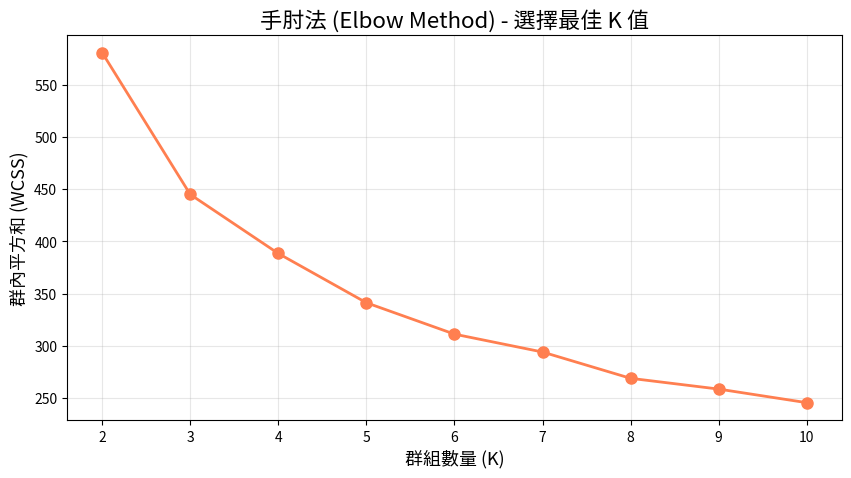

In [70]:
# 手肘法(Elbow Method)尋找最佳的 K 值
wcss = []
k_range = range(2, 11)

for k in k_range:
  kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42, n_init = 10)
  kmeans.fit(df_WHR_scaled)
  wcss.append(kmeans.inertia_) #計算群內平方和

# 繪製手肘法圖形
plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', linewidth=2, markersize=8, color='coral')
plt.title('手肘法 (Elbow Method) - 選擇最佳 K 值', fontsize=16, fontweight='bold')
plt.xlabel('群組數量 (K)', fontsize=13)
plt.ylabel('群內平方和 (WCSS)', fontsize=13)
plt.xticks(k_range)
plt.grid(alpha = 0.3)
plt.savefig('elbow_method.png')
plt.show()

In [71]:
# 輪廓係數 (Silhouette Score) - 驗證最佳 K 值
silhouette_scores = []

for k in k_range:
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  labels = kmeans.fit_predict(df_WHR_scaled)
  score = silhouette_score(df_WHR_scaled, labels)
  silhouette_scores.append(score)

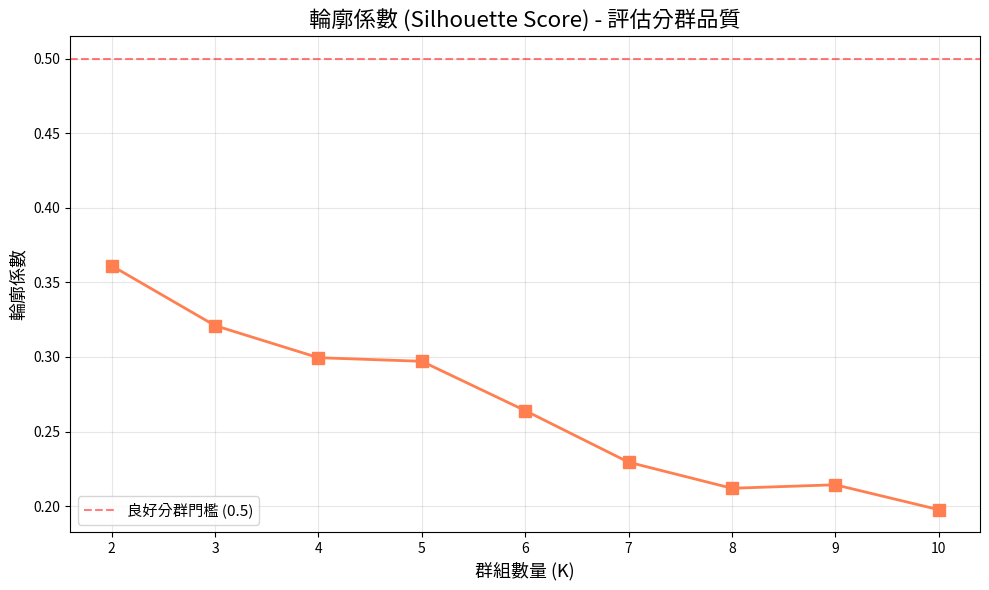


✅ 輪廓係數最高的 K 值: 2
   對應的輪廓係數: 0.361

💡 輪廓係數範圍 [-1, 1]:
   - 接近 1：分群非常好
   - 接近 0：資料點在群組邊界上
   - 接近 -1：分群錯誤


In [72]:
# 繪製輪廓係數圖
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='coral')
plt.title('輪廓係數 (Silhouette Score) - 評估分群品質', fontsize=16, fontweight='bold')
plt.xlabel('群組數量 (K)', fontsize=13)
plt.ylabel('輪廓係數', fontsize=13)
plt.xticks(k_range)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='良好分群門檻 (0.5)')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 找出最佳 K 值
best_k = k_range[np.argmax(silhouette_scores)]
print(f"\n✅ 輪廓係數最高的 K 值: {best_k}")
print(f"   對應的輪廓係數: {max(silhouette_scores):.3f}")
print("\n💡 輪廓係數範圍 [-1, 1]:")
print("   - 接近 1：分群非常好")
print("   - 接近 0：資料點在群組邊界上")
print("   - 接近 -1：分群錯誤")

In [73]:
optimal_k = 3  # 根據手肘法和輪廓係數的結果後綜合評估

kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10, max_iter=300)

cluster_labels = kmeans_model.fit_predict(df_WHR_scaled)

# 將分群結果加回原始資料
df_WHR['Cluster'] = cluster_labels

/tmp/ipykernel_894/165323310.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WHR['Cluster'] = cluster_labels


In [74]:
print(f"--- K-means 分群完成 (K={optimal_k}) ---")
print("\n各群組的國家數量：")
print(df_WHR['Cluster'].value_counts().sort_index())

print("\n各群組佔比：")
print((df_WHR['Cluster'].value_counts(normalize=True).sort_index() * 100).round(2))

--- K-means 分群完成 (K=3) ---

各群組的國家數量：
Cluster
0    69
1    48
2    23
Name: count, dtype: int64

各群組佔比：
Cluster
0    49.29
1    34.29
2    16.43
Name: proportion, dtype: float64


In [75]:
# 為了視覺化高維資料，我們先用 PCA 降到 2 維
pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(df_WHR_scaled)

# 建立 PCA DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


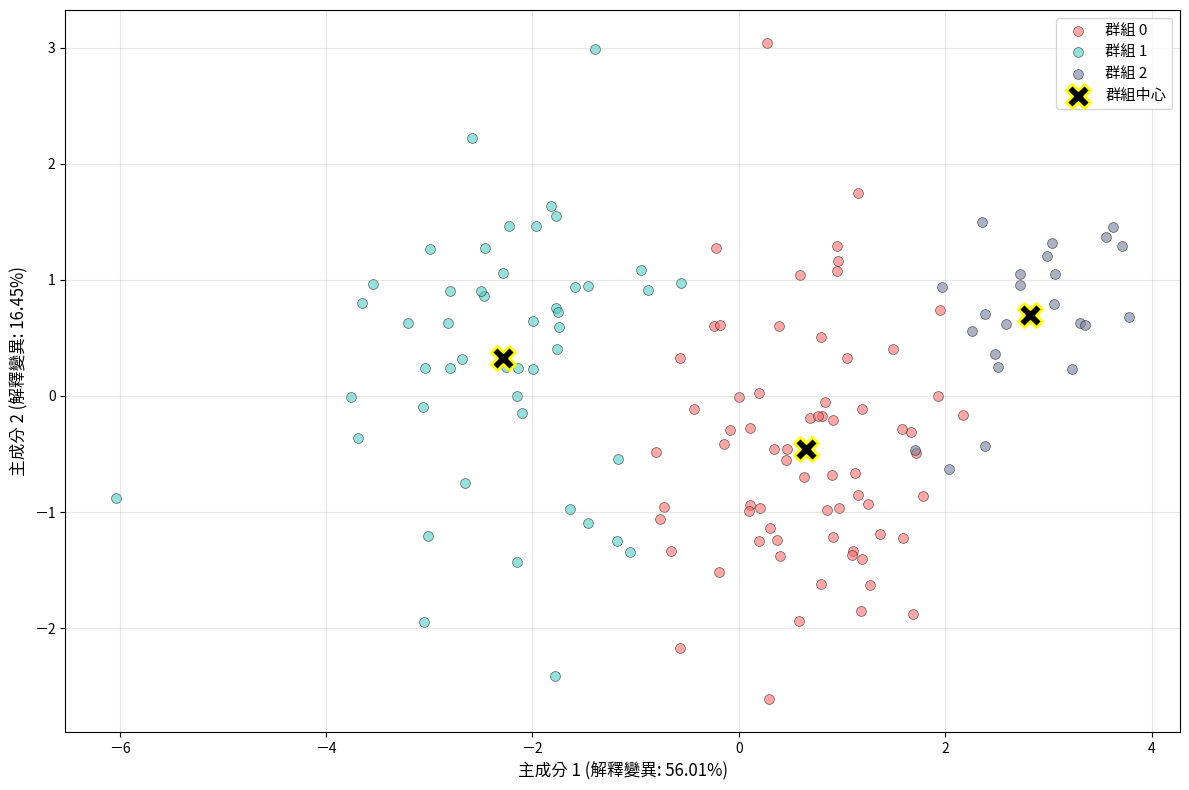

✅ PCA 降維完成！前兩個主成分解釋了 72.46% 的總變異


In [76]:
# 繪製散佈圖

plt.figure(figsize=(12, 8))
colors = ['#FF6B6B', '#4ECDC4', '#75809C', '#FFA07A', '#98D8C8']

for i in range(optimal_k):
    cluster_data = pca_df[pca_df['Cluster'] == i]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                c=colors[i], label=f'群組 {i}',
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# 繪製群組中心點
centers_pca = pca.transform(kmeans_model.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=300,
            edgecolors='yellow', linewidth=2,
            label='群組中心', zorder=5)


plt.xlabel(f'主成分 1 (解釋變異: {pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
plt.ylabel(f'主成分 2 (解釋變異: {pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ PCA 降維完成！前兩個主成分解釋了 {sum(pca.explained_variance_ratio_):.2%} 的總變異")

In [77]:
# 計算各群組的平均值
cluster_profile = df_WHR.groupby('Cluster')[Features].mean()

print("--- 各群組的特徵輪廓 (平均值) ---")
print(cluster_profile.round(2))

--- 各群組的特徵輪廓 (平均值) ---
         Log GDP per capita  Social support  Healthy life expectancy  \
Cluster                                                                
0                      1.53            1.29                     0.59   
1                      0.92            0.77                     0.34   
2                      1.90            1.42                     0.70   

         Freedom to make life choices  Generosity  Perceptions of corruption  
Cluster                                                                       
0                                0.65        0.13                       0.11  
1                                0.51        0.15                       0.11  
2                                0.75        0.19                       0.38  


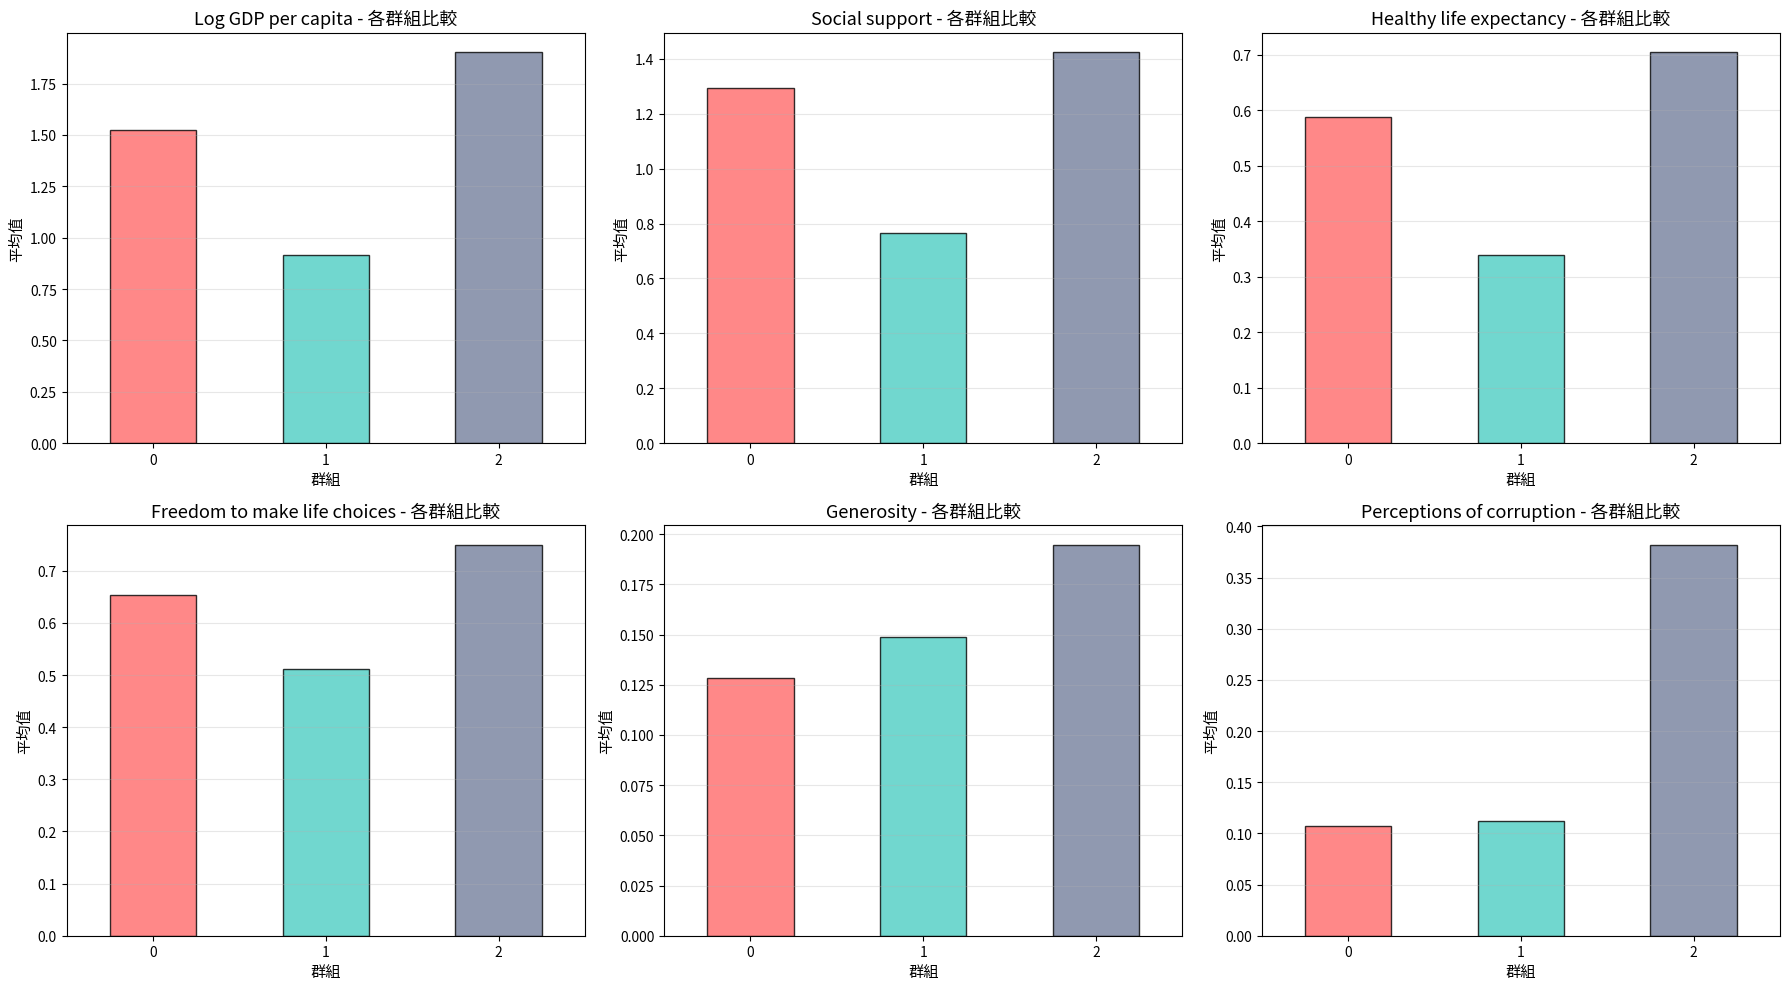

In [78]:
# 視覺化群組輪廓
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(Features):
    cluster_profile[feature].plot(kind='bar', ax=axes[idx],
                                   color=colors[:optimal_k], alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'{feature} - 各群組比較', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('群組', fontsize=11)
    axes[idx].set_ylabel('平均值', fontsize=11)
    axes[idx].grid(alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

###分群解讀
####(Cluster 0) 發展中奮鬥組 - "The Strivers"
####(Cluster 1) 生存挑戰組 - "The Strugglers"
####(Cluster 2) 幸福繁榮組 - "The Thrivers"


###(2.) 階層式分群法 (Hierarchical Clustering)

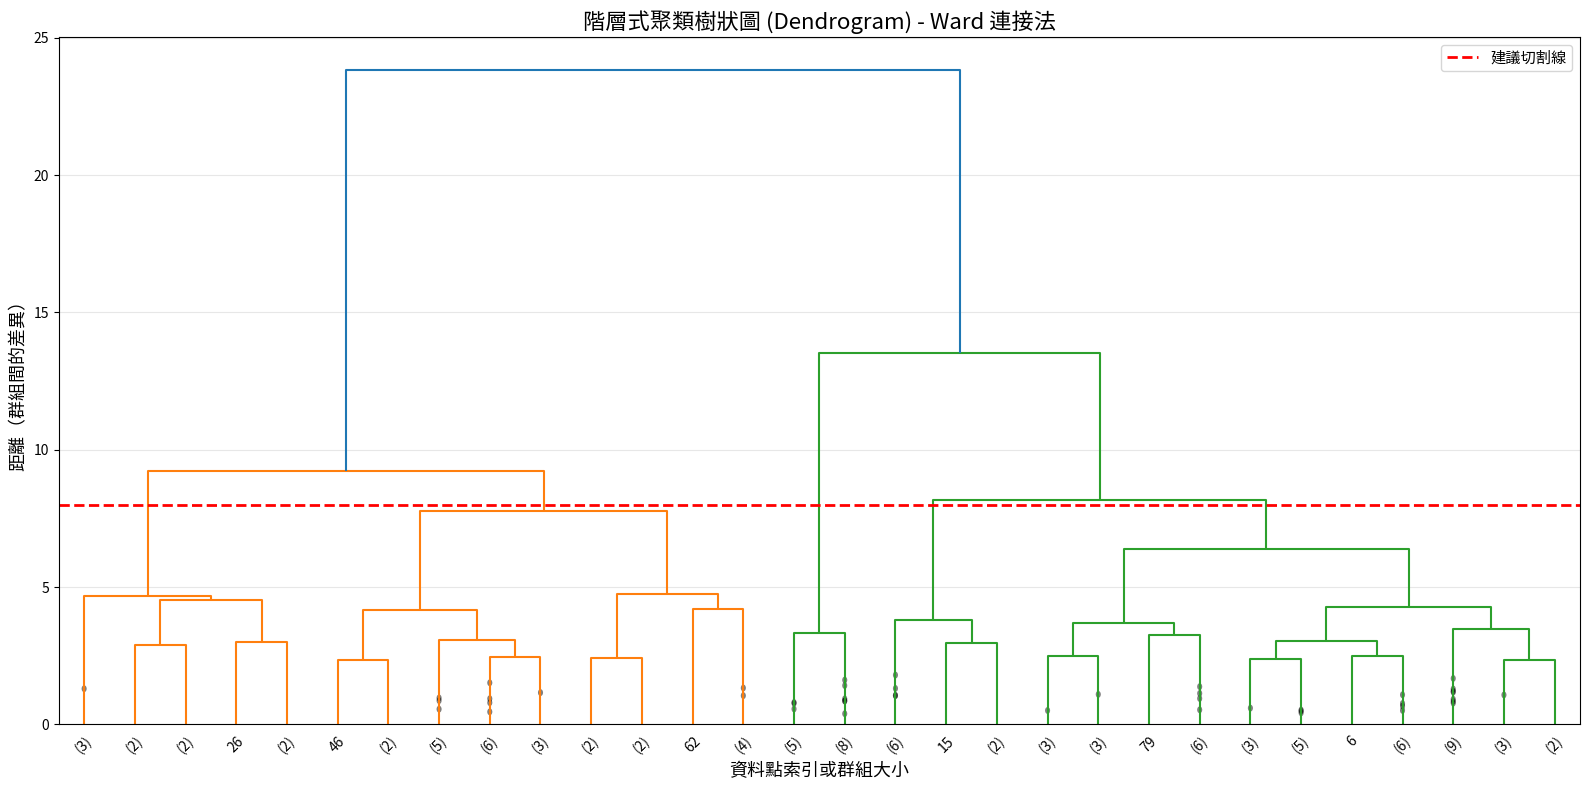

In [79]:
# 建立階層式聚類並繪製樹狀圖
sample_size = 100
df_sample = df_WHR_scaled.sample(n=sample_size, random_state=42)

# 使用 Ward 方法計算連接矩陣
linkage_matrix = linkage(df_sample, method='ward')

# 繪製樹狀圖
plt.figure(figsize=(16, 8))

dendrogram(linkage_matrix,
      truncate_mode='lastp',
      p=30,
      leaf_font_size=10,
      show_contracted=True)

plt.title('階層式聚類樹狀圖 (Dendrogram) - Ward 連接法', fontsize=16, fontweight='bold')
plt.xlabel('資料點索引或群組大小', fontsize=13)
plt.ylabel('距離（群組間的差異）', fontsize=13)
plt.axhline(y=8, color='red', linestyle='--', linewidth=2, label='建議切割線')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [80]:
# 執行階層式聚類
n_clusters_hierarchical = 3

hierarchical_model = AgglomerativeClustering(n_clusters = n_clusters_hierarchical,
                                  linkage = 'ward')
hierarchical_labels = hierarchical_model.fit_predict(df_WHR_scaled)
# 計算輪廓係數
hierarchical_silhouette = silhouette_score(df_WHR_scaled, hierarchical_labels)

In [81]:
print(f"--- 階層式聚類完成 (群組數={n_clusters_hierarchical}) ---")
print(f"輪廓係數: {hierarchical_silhouette:.3f}")
print("\n各群組的國家數：")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

# 與 K-means 結果比較
comparison_df = pd.DataFrame({
    'K-means': cluster_labels,
    'Hierarchical': hierarchical_labels
})

print("\n--- K-means vs 階層式聚類比較 ---")
print(pd.crosstab(comparison_df['K-means'], comparison_df['Hierarchical'],
                  rownames=['K-means'], colnames=['Hierarchical']))

--- 階層式聚類完成 (群組數=3) ---
輪廓係數: 0.284

各群組的國家數：
0    65
1    57
2    18
Name: count, dtype: int64

--- K-means vs 階層式聚類比較 ---
Hierarchical   0   1   2
K-means                 
0             17  52   0
1             48   0   0
2              0   5  18


#Step 3. 發現與結論

####我們依據2024年世界幸福報告數據，探討影響國家幸福感的關鍵因素，並對國家進行分類。

####主要觀察到不同地理區域在幸福感及其構成因素上存在顯著差異。例如，西歐、北美和澳紐地區在多數幸福指標上得分較高。相關係數分析顯示，社會支持、人均GDP（取對數）和健康預期壽命與幸福指數呈高度正相關，其中社會支持對幸福感的影響尤為突出，略高於人均GDP。

####我們建立線性迴歸模型預測幸福指數，模型表現良好，R-squared值約為0.843，表明所選特徵能有效解釋幸福指數的變異。模型結果指出，自由選擇生活是影響幸福指數最關鍵的因素，其次為社會支持和健康預期壽命。

####並且透過K-Means分群將國家分為三大類：
#####1. 發展中奮鬥組 (Cluster 0): 此組國家在各項指標上表現中等，處於發展中階段，正努力提升公民幸福感。
#####2. 生存挑戰組 (Cluster 1): 此組國家在所有幸福指標上得分皆較低，面臨較大的發展挑戰。
#####3. 幸福繁榮組 (Cluster 2): 此組國家通常具有高人均GDP、高社會支持、高健康預期壽命、高自由度及較高的腐敗認知，幸福指數亦最高。

####階層式分群法提供類似的國家分群結果，進一步驗證了這些群組的穩定性。台灣的數據被歸類在幸福繁榮組 (Cluster 2)，此表明台灣在上述幸福指標上與該組國家具有相似的特徵。

####=> 綜合而言，一個國家的幸福感深受經濟發展（人均GDP）、社會連結（社會支持）、公民健康（健康預期壽命）、個人自主性（自由選擇生活）及政府治理（腐敗認知）的影響。這些因素共同塑造了不同國家的幸福格局，並可將國家劃分為具有不同發展階段及幸福水平的群體。